## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import os

file_path = "../data/processed/cleaned_crime_data.csv"
print(os.path.abspath(file_path))
print(os.path.exists(file_path)) #checks if the file exists

df = pd.read_csv(file_path) #read the csv
print(df.shape) #counst how many rows and columns
print(df.columns.tolist()) #show column names
print(df["Record type"].value_counts()) #counts how many records are crime vs outcome

/Users/thadshasivashanker/Documents/rockborne /python/crime-analysis-project/data/processed/cleaned_crime_data.csv
True
(7289719, 14)
['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Outcome type', 'PoliceForce', 'Crime type', 'Last outcome category', 'Record type']
Crime      3867981
Outcome    3421738
Name: Record type, dtype: int64


## Dataset Overview 

In [3]:
df = pd.read_csv("../data/processed/cleaned_crime_data.csv")
print(df.shape)
print(df["Record type"].value_counts())

(7289719, 14)
Crime      3867981
Outcome    3421738
Name: Record type, dtype: int64


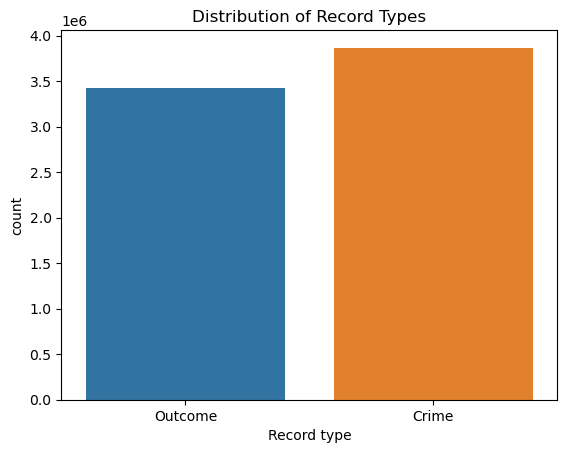

In [4]:
sns.countplot(data=df, x="Record type") #visualise how mnay crime and outcome record are in the dataset
plt.title("Distribution of Record Types")
plt.show()

In [5]:
import matplotlib as mpl #change the format of the numbers

mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False
mpl.rcParams['axes.formatter.limits'] = (-10, 10)

## Crimes Counts by Police Force 

In [6]:
crime_df = df[df["Record type"] == "Crime"] #filter the dataset to include only crime records
crime_df["Reported by"].value_counts() # count number of crime records reported by each police force

Metropolitan Police Service    2062997
West Midlands Police            653079
West Yorkshire Police           596848
Thames Valley Police            385991
Surrey Police                   169066
Name: Reported by, dtype: int64

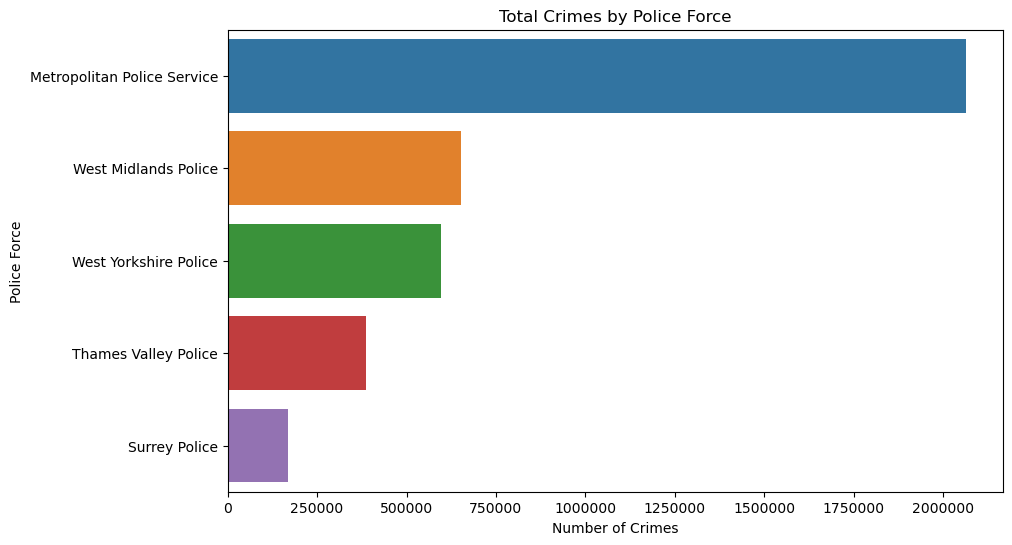

In [7]:
crime_df = df[df["Record type"] == "Crime"].copy()
crime_counts = crime_df["Reported by"].value_counts() # count crimes for each police force
plt.figure(figsize=(10,6)) #create a bar chart of total crimes by police force
sns.barplot(
    x=crime_counts.values,
    y=crime_counts.index)
plt.title("Total Crimes by Police Force")
plt.xlabel("Number of Crimes")
plt.ylabel("Police Force")
plt.show()

## Distribution of Crime Types

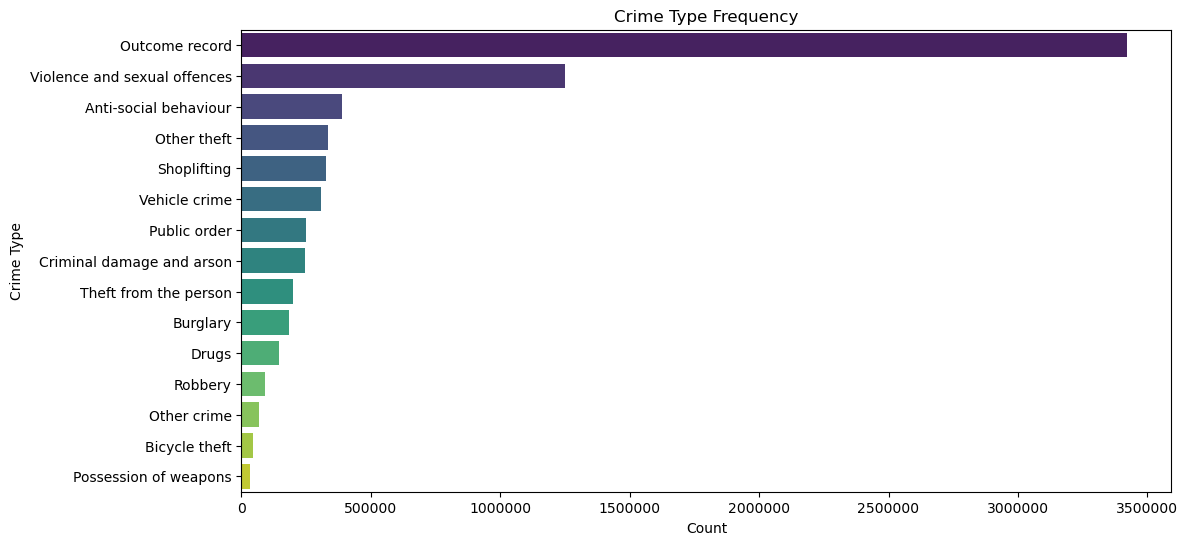

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Crime type', order=df['Crime type'].value_counts().index, palette='viridis')
plt.title("Crime Type Frequency")
plt.xlabel("Count")
plt.ylabel("Crime Type")
plt.show()

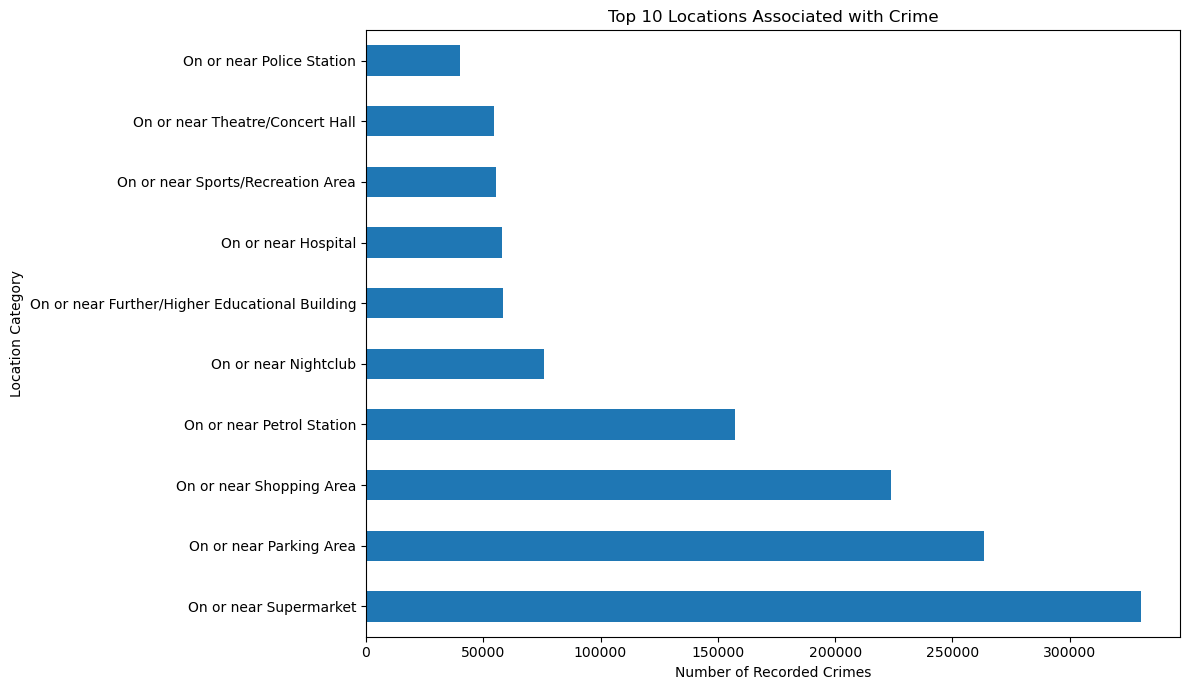

In [16]:
location_counts = df['Location'].value_counts().head(10) #find the top 10 most common locations
plt.figure(figsize=(12,7)) #plot bar chart
location_counts.plot(kind='barh')
plt.title("Top 10 Locations Associated with Crime")
plt.xlabel("Number of Recorded Crimes")
plt.ylabel("Location Category")
plt.tight_layout()
plt.show()

## Monthly Crime Trends Across Police Forces

To understand how crime levels change over time, monthly crime counts were calculated for each police force. 

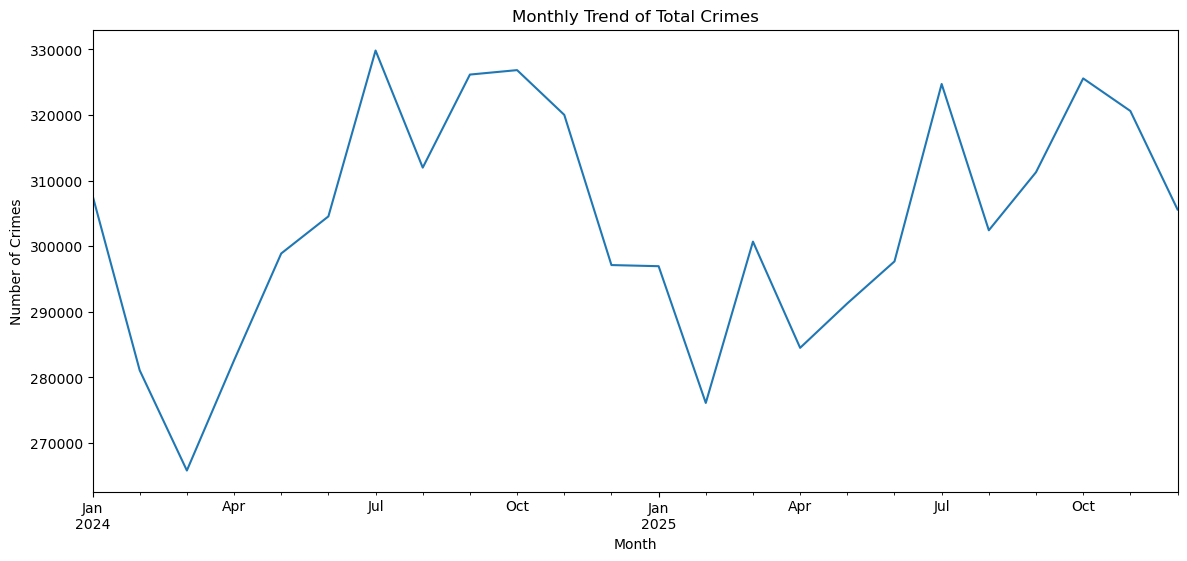

In [10]:
df['Month'] = pd.to_datetime(df['Month']) # converting month column to datetimeformat
df['Year-Month'] = df['Month'].dt.to_period('M') #extract year and month together for easier grouping
plt.figure(figsize=(14,6)) # count records per month and plot overall trend
df['Year-Month'].value_counts().sort_index().plot(kind='line')
plt.title("Monthly Trend of Total Crimes")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()

Month                  2025-07-01 00:00:00
Reported by    Metropolitan Police Service
Crime Count                          94797
Name: 90, dtype: object
Month          2025-02-01 00:00:00
Reported by          Surrey Police
Crime Count                   5849
Name: 66, dtype: object


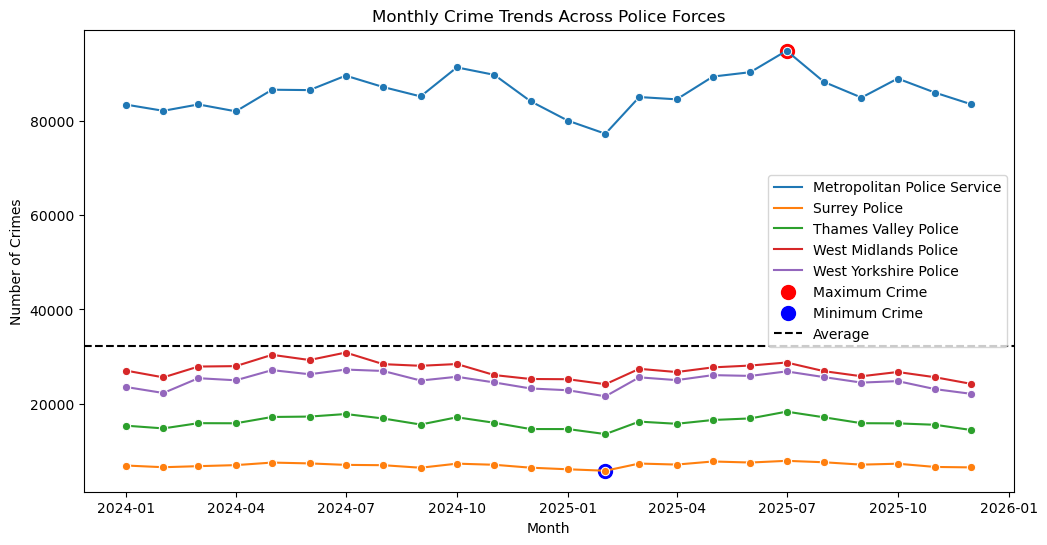

In [11]:
crime_df = df[df["Record type"] == "Crime"].copy() #only look at crime record 
crime_df["Month"] = pd.to_datetime(crime_df["Month"])
monthly_crime = crime_df.groupby(
    ["Month", "Reported by"]
).size().reset_index(name="Crime Count")

average_crime = monthly_crime["Crime Count"].mean() # calculate the average monthly crime count

max_point = monthly_crime.loc[monthly_crime["Crime Count"].idxmax()] #max monthly crime count
min_point = monthly_crime.loc[monthly_crime["Crime Count"].idxmin()] #min monthly crime count
print(max_point)
print(min_point)

plt.figure(figsize=(12,6)) #plot monthly crime trends for each police force
sns.lineplot(
    data=monthly_crime,
    x="Month",
    y="Crime Count",
    hue="Reported by",
    marker="o")
plt.scatter(
    max_point["Month"],
    max_point["Crime Count"],
    color="red",
    s=100,
    label="Maximum Crime")
plt.scatter(
    min_point["Month"],
    min_point["Crime Count"],
    color="blue",
    s=100,
    label="Minimum Crime")
plt.axhline( #add a horizontal line for the average monthly crime count
    monthly_crime["Crime Count"].mean(),
    color="black",
    linestyle="--",
    label="Average")
plt.title("Monthly Crime Trends Across Police Forces")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.legend()
plt.show()

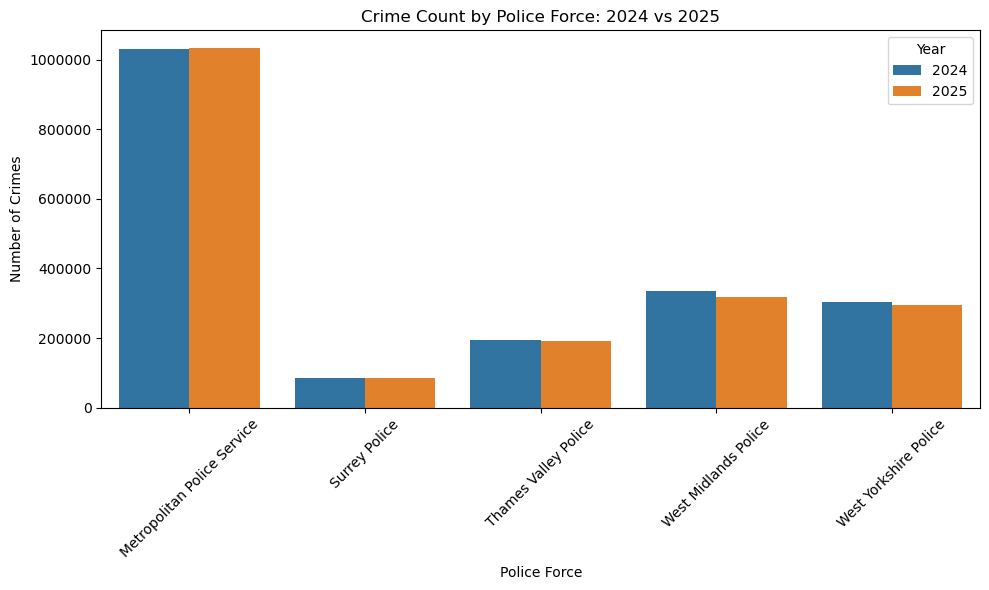

In [12]:
crime_df['Year'] = pd.to_datetime(crime_df['Month']).dt.year
year_counts = crime_df.groupby(['Reported by','Year']).size().reset_index(name='Crime_Count')# count total crimes by police force and year
import seaborn as sns
plt.figure(figsize=(10,6)) # create grouped bar chart
sns.barplot(data=year_counts,
            x='Reported by',
            y='Crime_Count',
            hue='Year')

plt.title("Crime Count by Police Force: 2024 vs 2025")
plt.xlabel("Police Force")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Crime Type Distribution Across Police forces 

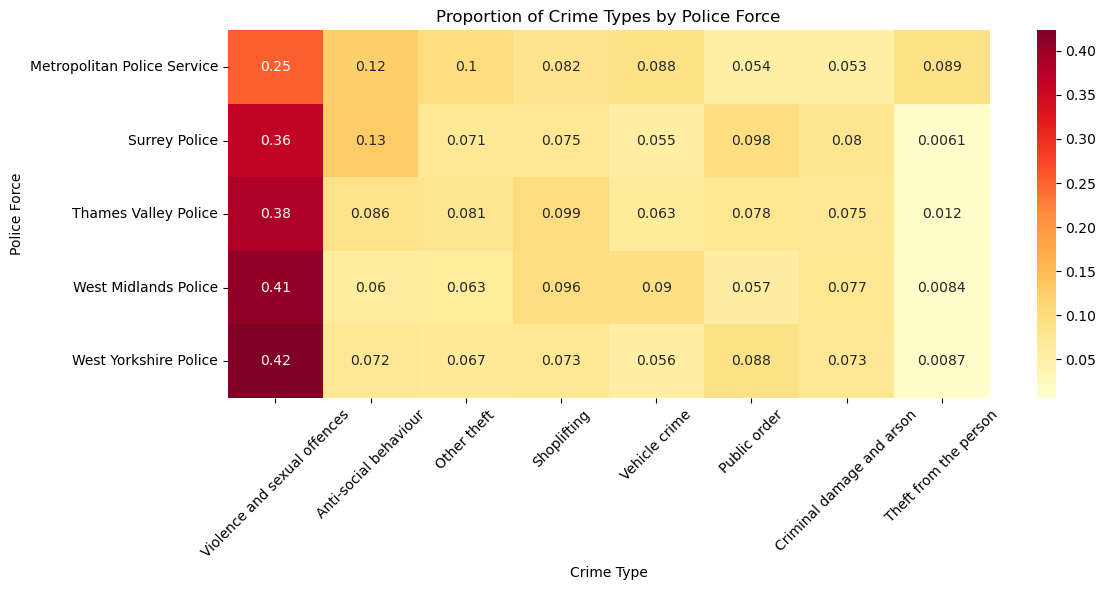

In [13]:
crime_counts = pd.crosstab(  #create a table of crime type counts for each police force
    crime_df["Reported by"],
    crime_df["Crime type"])
crime_counts.head() # create table of counts 

crime_type_prop = crime_counts.div(
    crime_counts.sum(axis=1),
    axis=0)
crime_type_prop.head() #converts into proportions 

top_crimes = crime_df["Crime type"].value_counts().head(8).index # keep only the top 8 most common crime types overall
crime_type_prop = crime_type_prop[top_crimes]

plt.figure(figsize=(12,6))#plot heatmap
sns.heatmap(
    crime_type_prop,
    cmap="YlOrRd",
    annot=True)
plt.title("Proportion of Crime Types by Police Force")
plt.xlabel("Crime Type")
plt.ylabel("Police Force")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Investigation Outcomes by Police Force

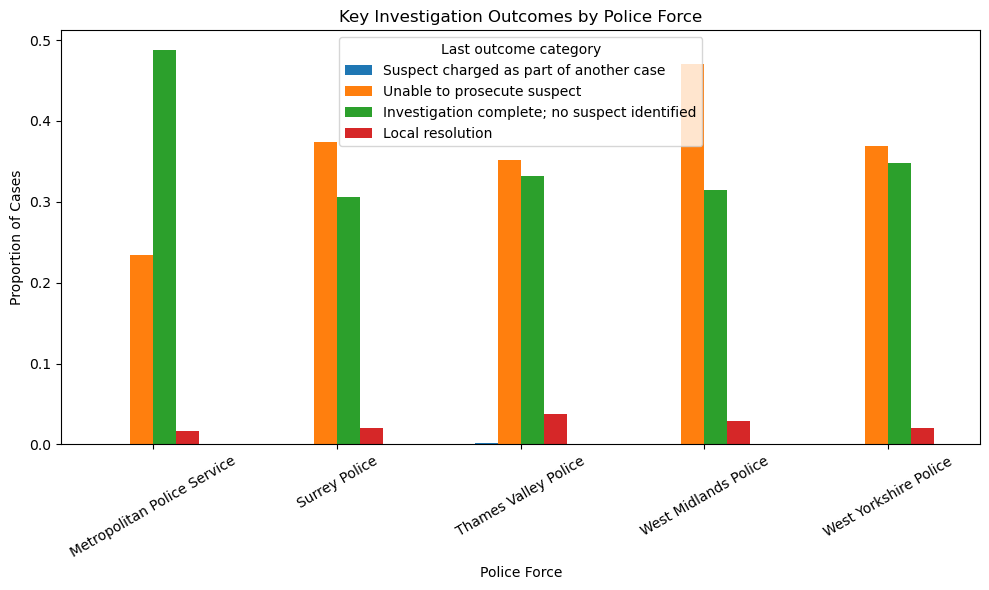

In [28]:
outcome_counts = pd.crosstab( 
    crime_df["Reported by"],
    crime_df["Last outcome category"]) #create a table of outcome counts by police force
outcome_prop = outcome_counts.div(
    outcome_counts.sum(axis=1),
    axis=0)
key_outcomes = [   # select key outcomes
    "Suspect charged as part of another case",
    "Unable to prosecute suspect",
    "Investigation complete; no suspect identified",
    "Local resolution"]
outcome_focus = outcome_prop[key_outcomes] # keep only selected outcomes
outcome_focus.plot( # plot bar chart
    kind="bar",
    figsize=(10,6))
plt.title("Key Investigation Outcomes by Police Force")
plt.xlabel("Police Force")
plt.ylabel("Proportion of Cases")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

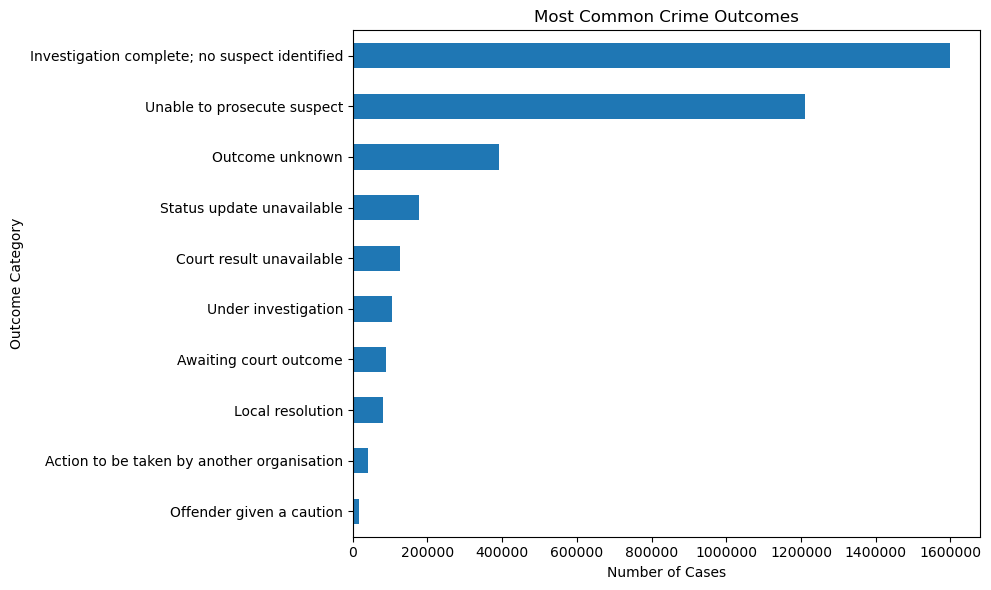

In [29]:
outcome_counts = crime_df['Last outcome category'].value_counts().head(10) # find the 10 most common outcome
plt.figure(figsize=(10,6))
outcome_counts.sort_values().plot(kind='barh') #plot barchart 
plt.title("Most Common Crime Outcomes")
plt.xlabel("Number of Cases")
plt.ylabel("Outcome Category")
plt.tight_layout()
plt.show()

In [30]:
crime_df['Last outcome category'].value_counts().head(20)

Investigation complete; no suspect identified          1599020
Unable to prosecute suspect                            1211159
Outcome unknown                                         390453
Status update unavailable                               178096
Court result unavailable                                126818
Under investigation                                     106176
Awaiting court outcome                                   88233
Local resolution                                         82212
Action to be taken by another organisation               39709
Offender given a caution                                 17222
Further investigation is not in the public interest       9956
Further action is not in the public interest              7987
Formal action is not in the public interest               5126
Offender given penalty notice                             4870
Suspect charged as part of another case                    937
Offender given a drugs possession warning              

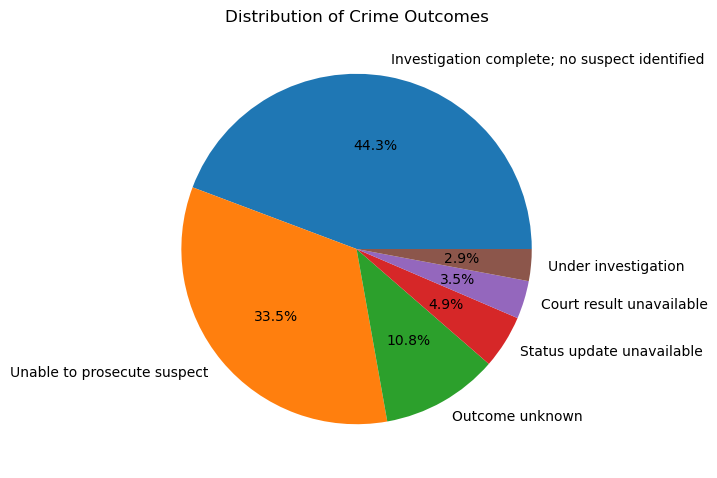

In [32]:
outcome_counts = crime_df['Last outcome category'].value_counts().head(6)
plt.figure(figsize=(7,7)) #show their percentage share in a pie chart
plt.pie(outcome_counts,
        labels=outcome_counts.index,
        autopct='%1.1f%%')
plt.title("Distribution of Crime Outcomes")
plt.tight_layout()
plt.show()

In [35]:
key_outcomes = [
    "Investigation complete; no suspect identified",
    "Unable to prosecute suspect",
    "Suspect charged as part of another case",
    "Local resolution"]
outcome_focus = crime_df["Last outcome category"].value_counts(normalize=True)[key_outcomes] * 100 #calculate percentage share of each chosen outcome
outcome_focus.round(2) #round
outcome_table = outcome_focus.round(2).reset_index()
outcome_table.columns = ["Outcome Category", "Percentage (%)"] # convert to table format
outcome_table

,Outcome Category,Percentage (%)
0,Investigation complete; no suspect identified,41.34
1,Unable to prosecute suspect,31.31
2,Suspect charged as part of another case,0.02
3,Local resolution,2.13


## Geographic Distribution 

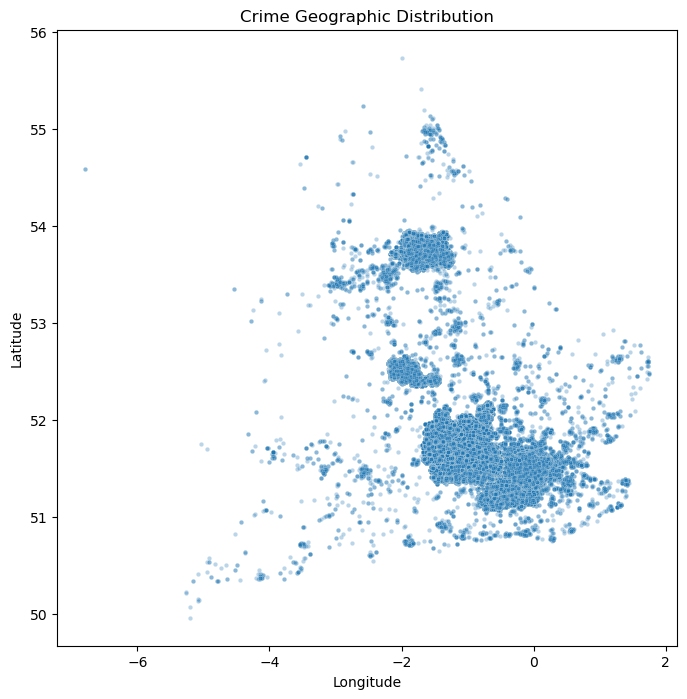

In [37]:
plt.figure(figsize=(8,8)) # plot all crime points using longitude and latitude
sns.scatterplot(data=df, x='Longitude', y='Latitude', alpha=0.3, s=10)
plt.title("Crime Geographic Distribution")
plt.show()

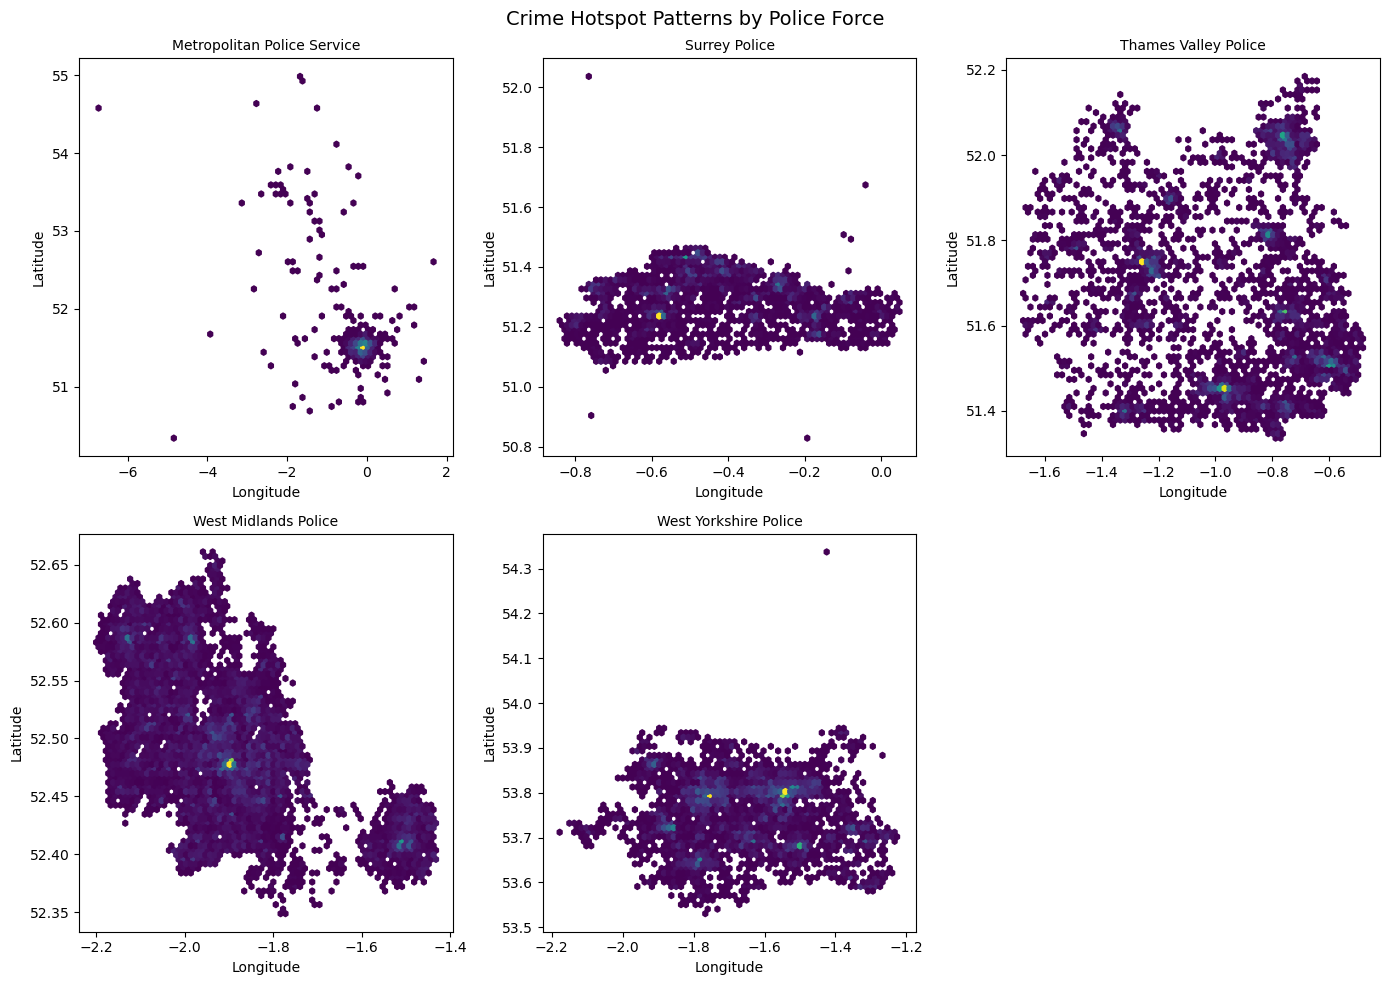

In [36]:
forces = [
    "Metropolitan Police Service",
    "Surrey Police",
    "Thames Valley Police",
    "West Midlands Police",
    "West Yorkshire Police"]
fig, axes = plt.subplots(2, 3, figsize=(14, 10)) # create subplots for each police force
axes = axes.flatten()
for i, force in enumerate(forces):
    temp = crime_df[
        (crime_df["Reported by"] == force) &
        crime_df["Longitude"].notna() &
        crime_df["Latitude"].notna()
    ].copy()
    
    if len(temp) > 50000:
        temp = temp.sample(50000, random_state=42)

    hb = axes[i].hexbin(
        temp["Longitude"],
        temp["Latitude"],
        gridsize=70,
        mincnt=1
    )
    axes[i].set_title(force, fontsize=10)
    axes[i].set_xlabel("Longitude")
    axes[i].set_ylabel("Latitude")

axes[-1].axis("off")
plt.suptitle("Crime Hotspot Patterns by Police Force", fontsize=14)
plt.tight_layout()
plt.show()

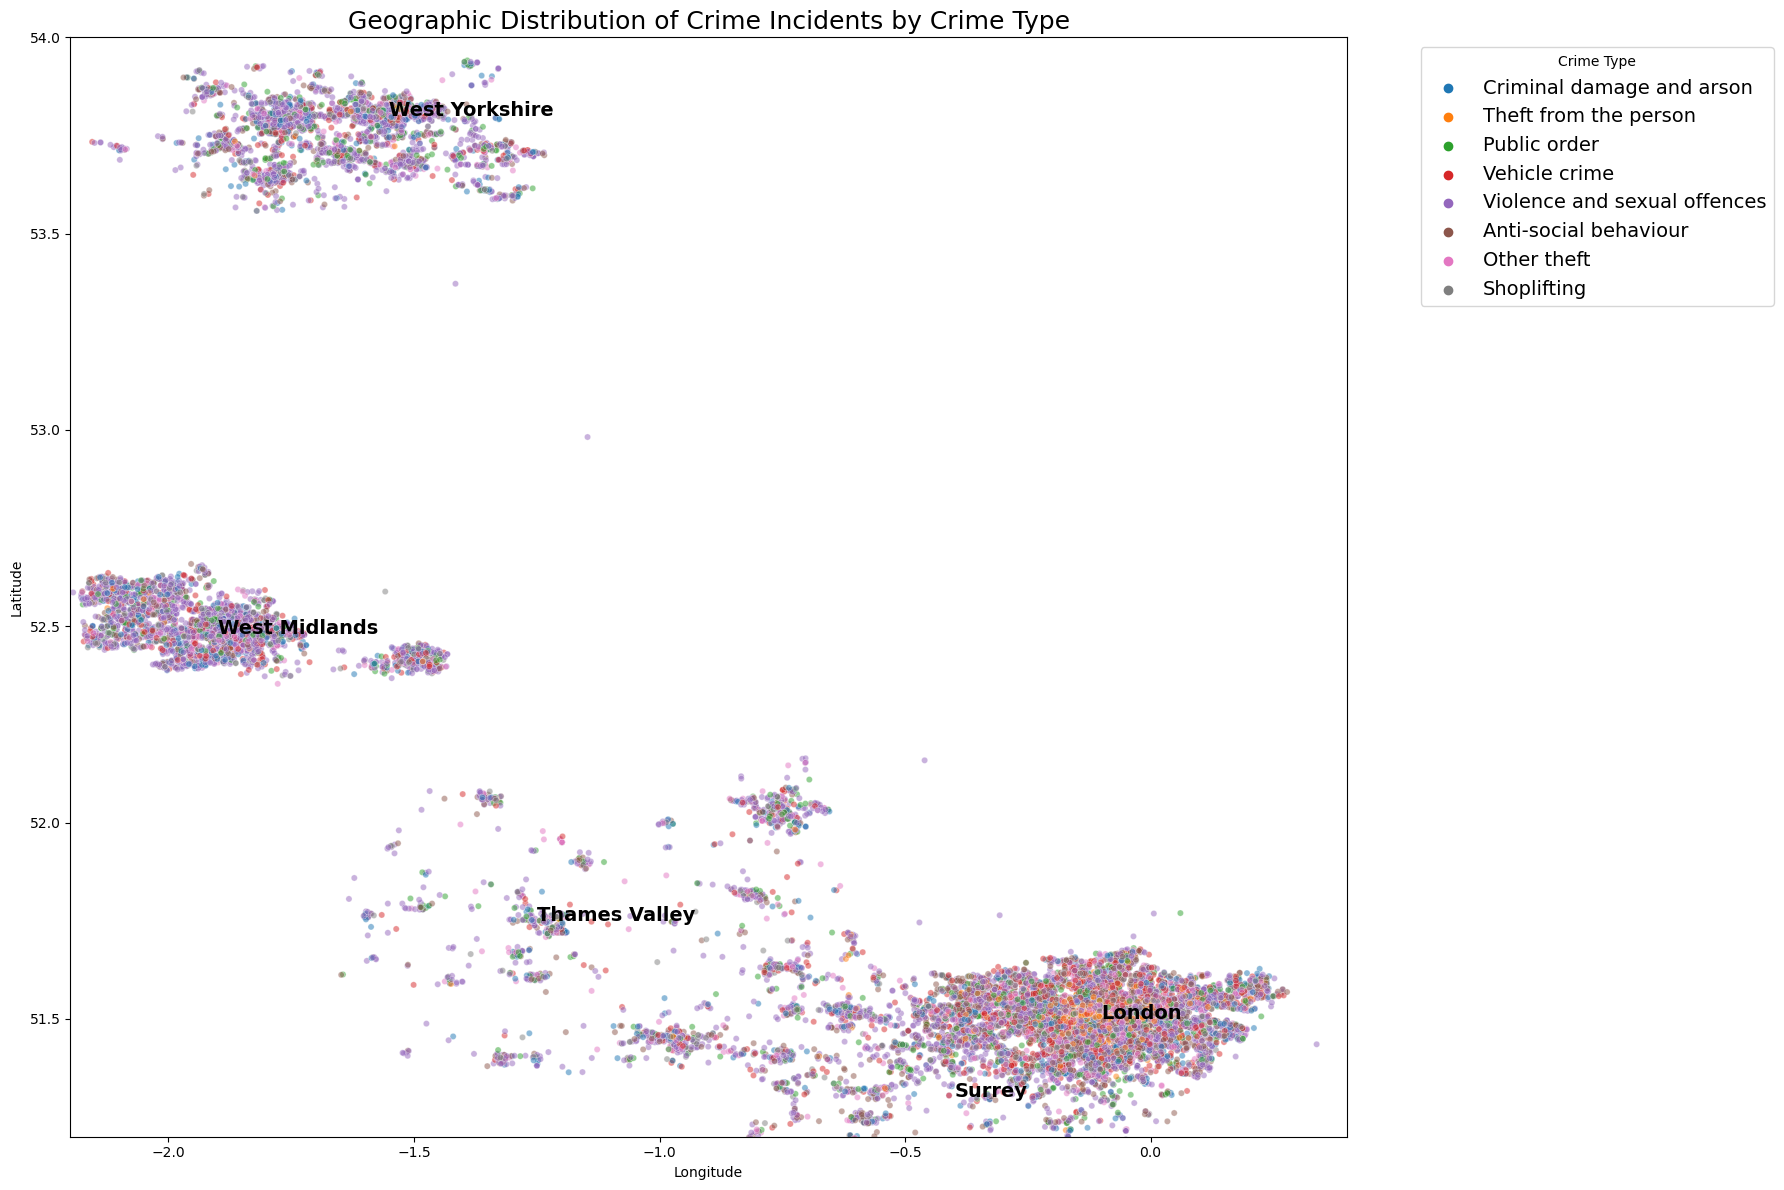

In [51]:
map_df = crime_df[
    (crime_df["Record type"] == "Crime") &
    crime_df["Longitude"].notna() &
    crime_df["Latitude"].notna() ].copy() # keep only crime records with coordinates
top_crimes = map_df["Crime type"].value_counts().head(8).index #top 8 only 
map_df = map_df[map_df["Crime type"].isin(top_crimes)]

map_df = map_df.sample(20000, random_state=42) # sample data 
plt.figure(figsize=(18,12))

sns.scatterplot(
    data=map_df,
    x="Longitude",
    y="Latitude",
    hue="Crime type",
    alpha=0.5,
    s=20)
plt.text(-0.1, 51.5, "London", fontsize=14, weight='bold')
plt.text(-1.9, 52.48, "West Midlands", fontsize=14, weight='bold')
plt.text(-1.55, 53.8, "West Yorkshire", fontsize=14, weight='bold')
plt.text(-1.25, 51.75, "Thames Valley", fontsize=14, weight='bold')
plt.text(-0.4, 51.3, "Surrey", fontsize=14, weight='bold')
plt.title("Geographic Distribution of Crime Incidents by Crime Type",fontsize=18)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Crime Type", fontsize=14)
plt.tight_layout()
plt.xlim(-2.2, 0.4)   # longitude range
plt.ylim(51.2, 54.0)  # latitude range
plt.show()

## Percentage difference vs the highest force

In [17]:
force_totals = crime_df['Reported by'].value_counts()
force_totals

Metropolitan Police Service    2062997
West Midlands Police            653079
West Yorkshire Police           596848
Thames Valley Police            385991
Surrey Police                   169066
Name: Reported by, dtype: int64

In [20]:
max_crime = force_totals.max()
percentage_vs_max = ((max_crime - force_totals) / max_crime) * 100
percentage_vs_max

Metropolitan Police Service     0.000000
West Midlands Police           68.343192
West Yorkshire Police          71.068887
Thames Valley Police           81.289793
Surrey Police                  91.804835
Name: Reported by, dtype: float64

In [19]:
crime_df['Crime type'].value_counts(normalize=True) * 100

Violence and sexual offences    32.337206
Anti-social behaviour           10.094491
Other theft                      8.658290
Shoplifting                      8.457306
Vehicle crime                    7.926513
Public order                     6.416164
Criminal damage and arson        6.364250
Theft from the person            5.157730
Burglary                         4.719129
Drugs                            3.774889
Robbery                          2.338533
Other crime                      1.771622
Bicycle theft                    1.138656
Possession of weapons            0.845221
Name: Crime type, dtype: float64

In [39]:
avg_monthly = force_totals / 24
avg_monthly.round(2)

Metropolitan Police Service    85958.21
West Midlands Police           27211.62
West Yorkshire Police          24868.67
Thames Valley Police           16082.96
Surrey Police                   7044.42
Name: Reported by, dtype: float64